In [ ]:
# Shared project setup for imports and file locations
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

DATA_DIR = PROJECT_ROOT / 'data'
ARTIFACTS_DIR = PROJECT_ROOT / 'artifacts'
FIGURES_DIR = PROJECT_ROOT / 'figures'

def resolve_path(path):
    candidate = Path(path)
    if candidate.exists():
        return candidate
    text = str(path).replace('\\', '/')
    name = Path(text).name
    special = {
        ARTIFACTS_DIR / 'controls' / 'positive_controls.pkl': ARTIFACTS_DIR / 'controls' / 'positive_controls.pkl',
        ARTIFACTS_DIR / 'controls' / 'negative_controls.pkl': ARTIFACTS_DIR / 'controls' / 'negative_controls.pkl',
        'Ten_positive_controls_1119.pkl': ARTIFACTS_DIR / 'controls' / 'positive_controls.pkl',
        'Ten_negative_controls_1119.pkl': ARTIFACTS_DIR / 'controls' / 'negative_controls.pkl',
        DATA_DIR / 'fcg.txt': DATA_DIR / 'fcg.txt',
    }
    if name in special:
        return special[name]
    matches = [p for p in PROJECT_ROOT.rglob(name) if '.ipynb_checkpoints' not in p.parts and '.git' not in p.parts]
    if len(matches) == 1:
        return matches[0]
    if (text.startswith('/Users/') or text.startswith('/home/') or ':\\' in text) and '.' not in name:
        return PROJECT_ROOT
    return candidate

from pdm_learn.preprocessing import build_density_map, density_centers, densitymap, drop_nan, extract, mut_trim, normalize, trim, trim_pairs
from pdm_learn.modeling import KFold_PR, LOOCV, LOOCV_grouped_plot, area_table, core_predict, heatmap, importance_test, ks_pvalue
from pdm_learn.simulation import eps, partition


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import integrate as scipy_int
from sympy import *

In [3]:
# Shared helper functions now live in src/pdm_learn.
# See the project setup cell at the top of this notebook for imports.


In [4]:
# Shared helper functions now live in src/pdm_learn.
# See the project setup cell at the top of this notebook for imports.


In [5]:
u = Symbol('u')
v = sqrt(1-u**2)
arr_x = partition(u, v, bounds=(-1,1), num=500).astype(float)
arr_y = np.array([v.subs(u, i).evalf() for i in arr_x]).astype(float)
arr_x /= np.std(arr_x)
arr_y /= np.std(arr_y)

In [5]:
base_func = pd.DataFrame()
u = Symbol('u')

v = u
arr_x = partition(u, v, bounds=(-1,1), num=500).astype(float)
arr_y = np.array([v.subs(u, i).evalf() for i in arr_x]).astype(float)
arr_x /= np.std(arr_x)
arr_y /= np.std(arr_y)
arr_x -= np.mean(arr_x)
arr_y -= np.mean(arr_y)
base_func = pd.concat([base_func, pd.DataFrame(arr_x).T, pd.DataFrame(arr_y).T], axis=0)

v = u**2
arr_x = partition(u, v, bounds=(-1,1), num=500).astype(float)
arr_y = np.array([v.subs(u, i).evalf() for i in arr_x]).astype(float)
arr_x /= np.std(arr_x)
arr_y /= np.std(arr_y)
arr_x -= np.mean(arr_x)
arr_y -= np.mean(arr_y)
base_func = pd.concat([base_func, pd.DataFrame(arr_x).T, pd.DataFrame(arr_y).T], axis=0)

v = sin(u)
arr_x = partition(u, v, bounds=(-pi,pi), num=500).astype(float)
arr_y = np.array([v.subs(u, i).evalf() for i in arr_x]).astype(float)
arr_x /= np.std(arr_x)
arr_y /= np.std(arr_y)
arr_x -= np.mean(arr_x)
arr_y -= np.mean(arr_y)
base_func = pd.concat([base_func, pd.DataFrame(arr_x).T, pd.DataFrame(arr_y).T], axis=0)

v = Integer(0)
arr_x = partition(u, v, bounds=(0,1), num=251).astype(float)
arr_y = np.array([v.subs(u, i).evalf() for i in arr_x]).astype(float)
temp = arr_x.copy()
arr_x = np.append(arr_x, arr_y[1:-1])
arr_y = np.append(arr_y, temp[1:-1])
arr_x /= np.std(arr_x)
arr_y /= np.std(arr_y)
arr_x -= np.mean(arr_x)
arr_y -= np.mean(arr_y)
base_func = pd.concat([base_func, pd.DataFrame(arr_x).T, pd.DataFrame(arr_y).T], axis=0)

base_func

,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
0,-1.728590e+00,-1.721662,-1.714734,-1.707806,-1.700877,-1.693949,-1.687021,-1.680093,-1.673164,-1.666236,...,1.666236,1.673164,1.680093,1.687021,1.693949,1.700877,1.707806,1.714734,1.721662,1.728590e+00
0,-1.728590e+00,-1.721662,-1.714734,-1.707806,-1.700877,-1.693949,-1.687021,-1.680093,-1.673164,-1.666236,...,1.666236,1.673164,1.680093,1.687021,1.693949,1.700877,1.707806,1.714734,1.721662,1.728590e+00
0,-1.559529e+00,-1.555390,-1.551243,-1.547087,-1.542922,-1.538747,-1.534564,-1.530372,-1.526171,-1.521960,...,1.521959,1.526169,1.530371,1.534563,1.538746,1.542920,1.547085,1.551242,1.555389,1.559525e+00
0,1.898867e+00,1.881774,1.864691,1.847616,1.830551,1.813496,1.796450,1.779413,1.762386,1.745369,...,1.745380,1.762397,1.779424,1.796461,1.813507,1.830562,1.847627,1.864702,1.881785,1.898867e+00
0,-1.707071e+00,-1.701188,-1.695305,-1.689421,-1.683535,-1.677649,-1.671761,-1.665870,-1.659978,-1.654082,...,1.654081,1.659976,1.665869,1.671759,1.677648,1.683534,1.689419,1.695304,1.701187,1.707062e+00
0,-2.115226e-08,-0.016021,-0.032042,-0.048060,-0.064076,-0.080088,-0.096095,-0.112097,-0.128092,-0.144079,...,0.144058,0.128071,0.112076,0.096074,0.080067,0.064055,0.048039,0.032021,0.016000,-2.115226e-08
0,-7.758340e-01,-0.763470,-0.751106,-0.738742,-0.726378,-0.714015,-0.701651,-0.689287,-0.676923,-0.664559,...,-0.775834,-0.775834,-0.775834,-0.775834,-0.775834,-0.775834,-0.775834,-0.775834,-0.775834,-7.758340e-01
0,-7.733553e-01,-0.773355,-0.773355,-0.773355,-0.773355,-0.773355,-0.773355,-0.773355,-0.773355,-0.773355,...,2.208256,2.220679,2.233102,2.245526,2.257949,2.270372,2.282796,2.295219,2.307643,2.320066e+00


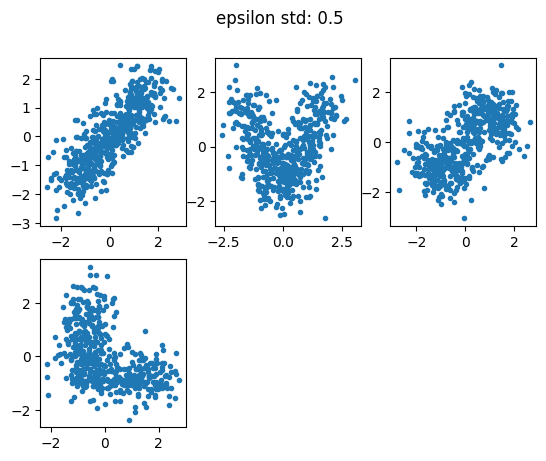

In [6]:
# visualize graphs
eps_std = 0.5

for i in range(0, len(base_func), 2):
    x = base_func[i:i+1]
    y = base_func[i+1:i+2]
    x = x + eps(np.size(x), eps_std)
    y = y + eps(np.size(y), eps_std)
    plt.subplot(2, 3, int(i/2+1))
    plt.scatter(x, y, marker='.')

plt.suptitle(f'epsilon std: {eps_std}')
plt.show()

In [21]:
# make simulated data sets
eps_std = 0
out = pd.DataFrame()

for i in range(0, len(base_func), 2):
    x = base_func[i:i+1].to_numpy()
    y = base_func[i+1:i+2].to_numpy()
    for _ in range(25):
        temp_x = x + eps(np.size(x), eps_std)
        temp_y = y + eps(np.size(y), eps_std)

        # normalize
        temp_x /= np.std(temp_x)
        temp_x -= np.mean(temp_x)
        temp_y /= np.std(temp_y)
        temp_y -= np.mean(temp_y)
        
        out = pd.concat([out, pd.DataFrame(temp_x), pd.DataFrame(temp_y)], axis=0)

out = out.reset_index(drop=True)
out

,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
0,-1.728590,-1.721662,-1.714734,-1.707806,-1.700877,-1.693949,-1.687021,-1.680093,-1.673164,-1.666236,...,1.666236,1.673164,1.680093,1.687021,1.693949,1.700877,1.707806,1.714734,1.721662,1.728590
1,-1.728590,-1.721662,-1.714734,-1.707806,-1.700877,-1.693949,-1.687021,-1.680093,-1.673164,-1.666236,...,1.666236,1.673164,1.680093,1.687021,1.693949,1.700877,1.707806,1.714734,1.721662,1.728590
2,-1.728590,-1.721662,-1.714734,-1.707806,-1.700877,-1.693949,-1.687021,-1.680093,-1.673164,-1.666236,...,1.666236,1.673164,1.680093,1.687021,1.693949,1.700877,1.707806,1.714734,1.721662,1.728590
3,-1.728590,-1.721662,-1.714734,-1.707806,-1.700877,-1.693949,-1.687021,-1.680093,-1.673164,-1.666236,...,1.666236,1.673164,1.680093,1.687021,1.693949,1.700877,1.707806,1.714734,1.721662,1.728590
4,-1.728590,-1.721662,-1.714734,-1.707806,-1.700877,-1.693949,-1.687021,-1.680093,-1.673164,-1.666236,...,1.666236,1.673164,1.680093,1.687021,1.693949,1.700877,1.707806,1.714734,1.721662,1.728590
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,-0.773355,-0.773355,-0.773355,-0.773355,-0.773355,-0.773355,-0.773355,-0.773355,-0.773355,-0.773355,...,2.208256,2.220679,2.233102,2.245526,2.257949,2.270372,2.282796,2.295219,2.307643,2.320066
196,-0.775834,-0.763470,-0.751106,-0.738742,-0.726378,-0.714015,-0.701651,-0.689287,-0.676923,-0.664559,...,-0.775834,-0.775834,-0.775834,-0.775834,-0.775834,-0.775834,-0.775834,-0.775834,-0.775834,-0.775834
197,-0.773355,-0.773355,-0.773355,-0.773355,-0.773355,-0.773355,-0.773355,-0.773355,-0.773355,-0.773355,...,2.208256,2.220679,2.233102,2.245526,2.257949,2.270372,2.282796,2.295219,2.307643,2.320066
198,-0.775834,-0.763470,-0.751106,-0.738742,-0.726378,-0.714015,-0.701651,-0.689287,-0.676923,-0.664559,...,-0.775834,-0.775834,-0.775834,-0.775834,-0.775834,-0.775834,-0.775834,-0.775834,-0.775834,-0.775834


In [22]:
out.to_csv(DATA_DIR / 'simulated' / 'positive.csv', index=False)

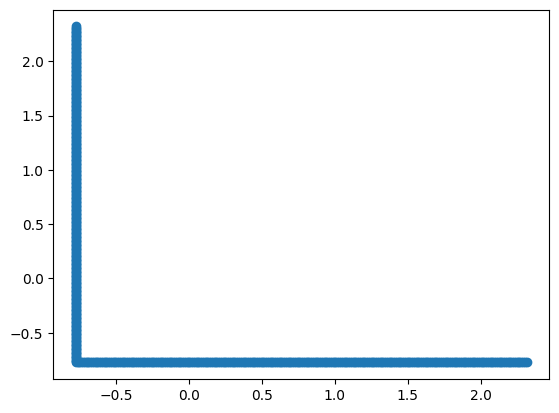

In [23]:
a = 198

plt.scatter(out[a:a+1], out[a+1:a+2])

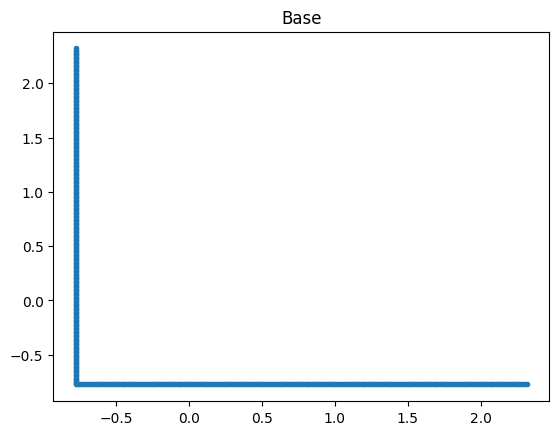

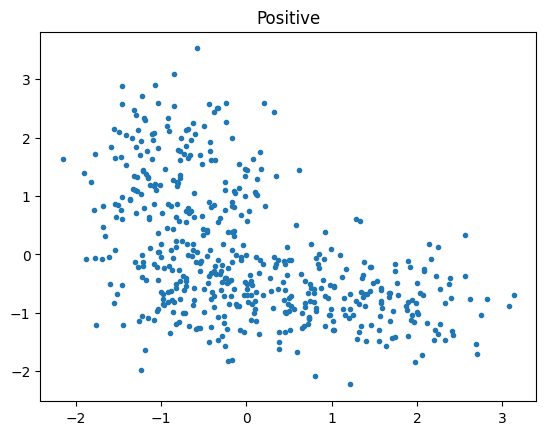

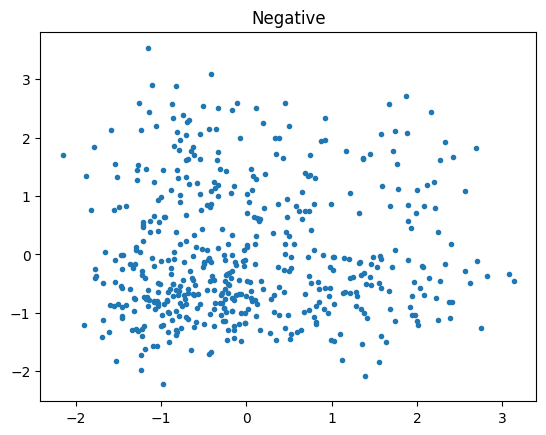

In [20]:
eps_std = 0.5
x = arr_x + eps(np.size(arr_x), eps_std)
y = arr_y + eps(np.size(arr_y), eps_std)

plt.scatter(arr_x, arr_y, marker='.')
plt.title('Base')
plt.show()

plt.scatter(x, y, marker='.')
plt.title('Positive')
plt.show()

np.random.default_rng().shuffle(y)
plt.scatter(x, y, marker='.')
plt.title('Negative')
plt.show()